# NB9 — Bajpai CRISPR orphans reconcile to the melanogenesis core under a *symmetric* STRING pull

**The project's primary finding. A third "the choice changes the answer" result — this time the choice is *seeding*.**

## TL;DR

| | |
|---|---|
| **What it establishes** | 142 of 169 CRISPR-validated melanin genes (Bajpai 2023) looked like "orphans" — in **no** curated pigmentation network — **not because they are biologically disconnected, but because our STRING pull was seeded only on the curated gene sets.** A STRING edge requires *both* endpoints in the query set, so an orphan↔curated edge was structurally impossible to observe. Re-querying STRING on the **full 714-gene union** (symmetric seed) reconciles **93 / 142** orphans to the melanogenesis core within ≤4 hops. |
| **Data + counts** | Bajpai 2023 genome-wide CRISPR screen (169 hits, KO reduces melanin). Curated-only STRING pull (`string_network_pulls_v12.json`, seed = 464 curated genes) vs symmetric pull (`string_union_symmetric_pull_v12.json`, seed = 714-gene union, 709 mapped, 5,446 edges @ score≥700). Core melanogenesis set = 23 genes (defined below). |
| **Contribution to flagship** | The third and most decisive "**the choice changes the answer**" result. NB5 showed network **source** drives 66%/34% membership drift; the tissue analyses showed **melanocyte-vs-bulk** flips locus calls; this shows **query seeding** flips the orphan count from **0 → 93**. All three say the same thing: the substrate is a *modeling choice*, not a ground truth. |
| **The one number that matters** | **0 → 93.** Under the curated-only seed, **0** of 142 orphans can reach the core (they cannot even enter the graph). Under the symmetric seed, **93** reach it within ≤4 STRING hops. |

## Honest split

- **93 reconciled** — connect to the core under the symmetric pull (network-completion result).
- **49 knowledge-gap residue** — CRISPR-validated melanin genes with **no** ≤4-hop path to canonical machinery *even under the symmetric pull*. A finding in its own right: experimentally causal, mechanistically unwired. Listed in §4.

## Guard rails (read before trusting any row)

- **STRING edges are association** — undirected, unsigned. A STRING path is a **hypothesis** (association-tier), never a mechanism. We do **not** coerce sign or direction onto it.
- **The CRISPR hit is the causal anchor.** Bajpai KO→reduced-melanin is the experimental evidence that the gene matters; STRING only supplies *candidate wiring* to explain how.
- **Bajpai sign is uniform** — all 169 hits have positive casTLE effect (knockout reduces pigmentation). There is no sign contrast to model.
- **Convergence is thin and we report it as such.** Of 93 reconciled, **92 are grade C** (STRING path only); GRN and Reactome corroborate **0**. 22/93 paths route through a promiscuous STRING hub (e.g. BRCA1, GRB2) and are flagged.

## 0 · Setup and frozen inputs

All inputs are **frozen in-repo** — no live network calls. Paths and checksums are verified before use.

In [ ]:
import json, hashlib
import pandas as pd, numpy as np, networkx as nx
from collections import Counter
pd.set_option('display.max_colwidth', 70)

import os
from pathlib import Path
REPO = str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd())
DBR  = f'{REPO}/data/external/db_responses'
PROC = f'{REPO}/data/processed'

FROZEN = {
    'symmetric_pull'  : f'{DBR}/string_union_symmetric_pull_v12.json',   # NEW symmetric seed
    'curated_pull'    : f'{DBR}/string_network_pulls_v12.json',          # OLD curated-only seed
    'reactome_pig'    : f'{DBR}/reactome_pigmentation_curated_union.json',
    'bajpai'          : f'{PROC}/bajpai2023_crispr_hits.csv',
    'membership'      : f'{PROC}/nb5_gene_set_membership.csv',
    'grn_edges'       : f'{PROC}/nb6_grn_edges.csv',
    'substrate_edges' : f'{PROC}/nb7_substrate_edges.csv',
}
def sha8(p):
    h=hashlib.sha256()
    with open(p,'rb') as f:
        for b in iter(lambda:f.read(1<<16), b''): h.update(b)
    return h.hexdigest()[:8]
import os
for k,p in FROZEN.items():
    assert os.path.exists(p), f'MISSING frozen input: {p}'
    print(f'{k:16} sha256={sha8(p)}  {os.path.basename(p)}')


symmetric_pull   sha256=278158c1  string_union_symmetric_pull_v12.json
curated_pull     sha256=68ab1569  string_network_pulls_v12.json
reactome_pig     sha256=ce1901ee  reactome_pigmentation_curated_union.json
bajpai           sha256=ebc197b6  bajpai2023_crispr_hits.csv
membership       sha256=6a818882  nb5_gene_set_membership.csv
grn_edges        sha256=1a1bd134  nb6_grn_edges.csv
substrate_edges  sha256=688c378f  nb7_substrate_edges.csv


In [ ]:
sym = json.load(open(FROZEN['symmetric_pull']))
old = json.load(open(FROZEN['curated_pull']))
react = json.load(open(FROZEN['reactome_pig']))
baj = pd.read_csv(FROZEN['bajpai'])
mem = pd.read_csv(FROZEN['membership'])
grn = pd.read_csv(FROZEN['grn_edges'])

print('symmetric pull :', sym['summary']['n_input_symbols'],'seed →',
      sym['summary']['n_mapped'],'mapped,', sym['summary']['n_edges'],'edges @ score>=700')
print('curated pull   :', len(old['results']['union_all']['query']['symbols']),
      'seed (union of 4 curated component pulls)')
print('Bajpai hits    :', len(baj))


symmetric pull : 714 seed → 709 mapped, 5446 edges @ score>=700
curated pull   : 464 seed (union of 4 curated component pulls)
Bajpai hits    : 169


## 1 · The core melanogenesis set and the 142 orphans

**Core melanogenesis set (23 genes, defined explicitly here — this is the target we ask orphans to reach):**
the canonical melanin-synthesis enzymes, melanosome structural/transport proteins, and the MITF/SOX10/EDN/KIT
axis that builds and regulates the melanosome.

An **orphan** = a Bajpai CRISPR hit that is in **none** of the curated sets (Raghunath-168, D'Arcy-243,
KEGG hsa04916, Reactome pigmentation) — i.e. `in_bajpai2023_crispr_169 == True` and `n_sets == 0` in the
NB5 membership table.

In [ ]:
CORE = ['TYR','TYRP1','DCT','MLANA','PMEL','OCA2','HERC2','MC1R','KIT','KITLG','MITF',
        'SLC45A2','SLC24A5','EDNRB','EDN3','POMC','ASIP','SOX10','PAX3','MLPH','RAB27A','MYO5A','GPR143']
CORE = set(CORE)

orphans = mem.loc[mem['in_bajpai2023_crispr_169'] & (mem['n_sets']==0), 'gene'].tolist()
orphan_set = set(orphans)
print('Core melanogenesis genes :', len(CORE))
print('Bajpai CRISPR hits        :', int(mem['in_bajpai2023_crispr_169'].sum()))
print('  of which ORPHANS (n_sets==0):', len(orphans))
assert len(orphans)==142, len(orphans)
# Bajpai sign is uniform — confirm
print('\nBajpai direction (all hits):', baj['direction_note'].str.contains('reduces').all(),
      '→ every KO reduces pigmentation (uniform positive-effector sign)')


Core melanogenesis genes : 23
Bajpai CRISPR hits        : 169
  of which ORPHANS (n_sets==0): 142

Bajpai direction (all hits): True → every KO reduces pigmentation (uniform positive-effector sign)


## 2 · The seeding artifact, demonstrated head-on

**The mechanism (state it plainly).** STRING returns an edge between gene A and gene B *only if both A and B
were in the query set you sent it.* Our original pull (`string_network_pulls_v12.json`) was seeded on the
curated gene sets only (464-gene union). The 142 orphans were **not in that query set** — so no edge between an
orphan and a curated/core gene could ever be returned. The orphans were not "disconnected"; they were
**never asked about.**

**The fix.** Re-query STRING seeded on the **full 714-gene union of every layer**
(Raghunath + Bajpai + D'Arcy + KEGG + Reactome). Now every orphan is in the query set, so orphan↔core edges
*can* appear. This is the only thing that changed — same STRING version (v12.0), same score threshold (≥700).

Below: build both graphs and count how many orphans reach the core under each seed. **This is the finding.**

In [ ]:
# STRING edges use the PREFERRED gene name, not the query symbol (e.g. KIAA1033 -> WASHC4).
# Map query symbol -> preferred name so orphans/core align with edge endpoints.
q2name = {n['query']: n['name'] for n in sym['nodes']}
core_names   = {q2name.get(c, c) for c in CORE}
orphan_names = {o: q2name.get(o, o) for o in orphans}

# --- Symmetric graph (name space) ---
Gsym = nx.Graph()
for e in sym['edges']:
    Gsym.add_edge(e['a'], e['b'], score=e['score'])
for n in sym['nodes']:
    Gsym.add_node(n['name'])

# --- Curated-only graph (union of the 4 curated component pulls) ---
Gcur = nx.Graph()
for k in ['raghunath_168','darcy_s1_243','kegg_hsa04916_101','reactome_r_hsa_5662702_5']:
    for e in old['results'][k]['edges']:
        Gcur.add_edge(e['a'], e['b'], score=e['score'])
    for n in old['results'][k]['nodes']:
        Gcur.add_node(n['name'])

print(f'Symmetric graph  : {Gsym.number_of_nodes():4d} nodes, {Gsym.number_of_edges():5d} edges')
print(f'Curated-only graph: {Gcur.number_of_nodes():4d} nodes, {Gcur.number_of_edges():5d} edges')
print(f'Core genes present — symmetric: {len(core_names & set(Gsym))}/23   curated-only: {len(core_names & set(Gcur))}/23')


Symmetric graph  :  709 nodes,  5446 edges
Curated-only graph:  462 nodes,  2973 edges
Core genes present — symmetric: 23/23   curated-only: 23/23


In [ ]:
def reaches_core(G, node, cores, cutoff):
    '''True if node reaches any core gene within `cutoff` hops.'''
    if node not in G: return False
    for c in cores:
        if c in G and nx.has_path(G, node, c) and nx.shortest_path_length(G, node, c) <= cutoff:
            return True
    return False

CUTOFF = 4
# Under the CURATED-ONLY seed: orphans are not even nodes -> cannot reach core
n_cur = sum(reaches_core(Gcur, orphan_names[o], core_names & set(Gcur), CUTOFF) for o in orphans)
n_cur_nodes = sum((o in Gcur) or (orphan_names[o] in Gcur) for o in orphans)
# Under the SYMMETRIC seed
n_sym = sum(reaches_core(Gsym, orphan_names[o], core_names & set(Gsym), CUTOFF) for o in orphans)

print('=== THE HEADLINE NUMBER ===')
print(f'Orphans present as a node in curated-only graph : {n_cur_nodes:3d} / 142')
print(f'Orphans reaching core (curated-only seed, <=4)  : {n_cur:3d} / 142')
print(f'Orphans reaching core (symmetric seed,  <=4)    : {n_sym:3d} / 142')
print(f'\n  0 -> {n_sym}   (seeding, not biology, produced the orphans)')


=== THE HEADLINE NUMBER ===
Orphans present as a node in curated-only graph :   0 / 142
Orphans reaching core (curated-only seed, <=4)  :   0 / 142
Orphans reaching core (symmetric seed,  <=4)    :  93 / 142

  0 -> 93   (seeding, not biology, produced the orphans)


## 3 · Per-orphan reconciliation: distance, path, and independent lines of evidence

For each of the 142 orphans we compute, in the **symmetric** graph:

1. **In symmetric graph?** — is the gene a node at all.
2. **Shortest-path distance to nearest core gene** (BFS, unweighted = fewest hops).
3. **Path intermediates** and the **weakest edge score** on that path (the path is only as strong as its
   weakest link; a low weakest-score is a fragile hypothesis).
4. **GRN-regulon membership** — is it a MITF/SOX10/PAX3 target (NB6, `nb6_grn_edges.csv`)?
5. **Reactome pigmentation-tagged** — is it in the curated Reactome pigmentation union?
6. **Direct core adjacency** — distance == 1.

**Convergence grade** (reconciled orphans only) = number of *independent* lines supporting the connection
(STRING path within cutoff, direct core edge, GRN edge, Reactome-pig tag):
**A** ≥3 lines · **B** = 2 lines · **C** = 1 line. A path routed through a promiscuous STRING hub
(BRCA1, GRB2, ACTB, …) is flagged `hub_mediated_path` — these are generic connectors and inflate reachability.

In [ ]:
def nearest_core(G, src, cores):
    best=None
    for c in cores:
        if c in G and nx.has_path(G, src, c):
            d=nx.shortest_path_length(G, src, c)
            if best is None or d<best[0]: best=(d,c)
    return best

def path_details(G, s, t):
    p=nx.shortest_path(G, s, t)
    sc=[G[p[i]][p[i+1]]['score'] for i in range(len(p)-1)]
    return p, p[1:-1], (min(sc) if sc else np.nan)

react_pig   = set(react['curated_union_genes'])
grn_targets = set(grn['target'])
HUBS = {'BRCA1','GRB2','ACTB','CUL5','APP','UBC','ELAVL1','MYC','EGFR','HSP90AA1','TP53','ESR1','EP300','CREBBP'}
core_in_sym = core_names & set(Gsym)
baj_idx = baj.set_index('Symbol')
BAJPAI_CIT='Bajpai et al. 2023 Science 381:eade6289 (DOI 10.1126/science.ade6289; PMC10901463)'
STRING_CIT='STRING v12.0 (Szklarczyk 2023, PMID 36370105); symmetric union pull score>=700, string_union_symmetric_pull_v12.json'

rows=[]
for o in orphans:
    nm=orphan_names[o]; in_sym = nm in Gsym
    nc = nearest_core(Gsym, nm, core_in_sym) if in_sym else None
    if nc:
        dist,cg = nc; p,inter,weak = path_details(Gsym, nm, cg)
        inter_str = ' | '.join(inter) if inter else '(direct)'; path_str=' -> '.join(p)
    else:
        dist=np.nan; cg=''; inter_str=''; path_str=''; weak=np.nan
    reached = (not np.isnan(dist)) and dist<=CUTOFF
    direct  = dist==1
    in_grn  = o in grn_targets
    react_t = o in react_pig
    n_lines = int(reached)+int(bool(direct))+int(in_grn)+int(react_t)
    if reached:
        grade = 'A' if n_lines>=3 else ('B' if n_lines==2 else 'C'); bucket='reconciled'
    else:
        grade=''; bucket='knowledge-gap'
    hub = bool(inter_str) and inter_str!='(direct)' and any(x.strip() in HUBS for x in inter_str.split('|'))
    castle = float(baj_idx.loc[o,'Combined_casTLE_Effect']) if o in baj_idx.index else np.nan
    cit = BAJPAI_CIT + (' | '+STRING_CIT if bucket=='reconciled' else '')
    rows.append(dict(gene=o, casTLE=castle, in_symmetric_graph=in_sym,
        dist_to_core=dist, nearest_core_gene=cg, path_intermediates=inter_str, path_full=path_str,
        weakest_edge_score=weak, in_GRN=in_grn, reactome_pig_tagged=react_t,
        direct_core_adjacency=bool(direct), hub_mediated_path=hub,
        n_convergence_lines=n_lines, convergence_grade=grade, bucket=bucket, citation=cit))

recon_df = pd.DataFrame(rows).sort_values(['bucket','dist_to_core','gene'], na_position='last').reset_index(drop=True)
print('reconciled  :', int((recon_df.bucket=="reconciled").sum()))
print('knowledge-gap:', int((recon_df.bucket=="knowledge-gap").sum()))
recon_df.head(6)[['gene','casTLE','dist_to_core','nearest_core_gene','path_full','weakest_edge_score','convergence_grade','bucket']]


reconciled  : 93
knowledge-gap: 49


,gene,casTLE,dist_to_core,nearest_core_gene,path_full,weakest_edge_score,convergence_grade,bucket
0,TMED2,1.3,5.0,POMC,TMED2 -> TMED10 -> PSENEN -> TNF -> CALM3 -> POMC,0.82,,knowledge-gap
1,AC002398.9,1.7,NaN,,,NaN,,knowledge-gap
2,ALKBH8,0.8,NaN,,,NaN,,knowledge-gap
3,B4GALT1,1.5,NaN,,,NaN,,knowledge-gap
4,BACE2,1.1,NaN,,,NaN,,knowledge-gap
5,BLOC1S5-TXNDC5,2.3,NaN,,,NaN,,knowledge-gap


In [ ]:
# Distance distribution + grade distribution (reconciled)
rec = recon_df[recon_df.bucket=='reconciled']
print('Distance-to-core distribution (reconciled):')
for d,c in rec['dist_to_core'].astype(int).value_counts().sort_index().items():
    print(f'   {d} hop(s): {c}')
print('\nConvergence grade distribution (reconciled):', rec['convergence_grade'].value_counts().to_dict())
print(f'Paths through a promiscuous STRING hub: {int(rec.hub_mediated_path.sum())}/{len(rec)}')
print(f'\nIndependent corroboration beyond STRING:')
print(f'   GRN-regulon targets among orphans   : {int(recon_df.in_GRN.sum())}')
print(f'   Reactome-pig-tagged among orphans   : {int(recon_df.reactome_pig_tagged.sum())}')
print(f'   direct core adjacency (dist==1)     : {int(recon_df.direct_core_adjacency.sum())}')
print('\n→ Reconciliation rests almost entirely on STRING association. This is the honest weakness.')


Distance-to-core distribution (reconciled):
   1 hop(s): 1
   2 hop(s): 38
   3 hop(s): 35
   4 hop(s): 19

Convergence grade distribution (reconciled): {'C': 92, 'B': 1}
Paths through a promiscuous STRING hub: 22/93

Independent corroboration beyond STRING:
   GRN-regulon targets among orphans   : 0
   Reactome-pig-tagged among orphans   : 0
   direct core adjacency (dist==1)     : 1

→ Reconciliation rests almost entirely on STRING association. This is the honest weakness.


## 4 · The honest split — reconciled vs knowledge-gap residue

- **(a) Reconciled (93)** — connect to the core within ≤4 STRING hops. The network-completion result:
  genes that *looked* orphaned only because of the seeding artifact. STRING supplies a candidate wiring
  hypothesis; the CRISPR hit is the causal anchor.
- **(b) Knowledge-gap residue (49)** — CRISPR-validated melanin genes with **no** ≤4-hop path to the core
  *even under the symmetric pull*. These are not artifacts of seeding: they are experimentally causal
  (KO reduces melanin) yet have **no known high-confidence interaction** wiring them to the canonical
  machinery. This is a genuine knowledge gap and a finding in its own right — the honest complement to the
  reconciliation result.

In [ ]:
gap = recon_df[recon_df.bucket=='knowledge-gap'].copy()
# split the residue by *why* it stays orphan
not_in_graph = gap[~gap.in_symmetric_graph]
in_graph_far = gap[gap.in_symmetric_graph]
print(f'Knowledge-gap residue: {len(gap)} orphans')
print(f'   not mapped into STRING at all      : {len(not_in_graph)}  {sorted(not_in_graph.gene)}')
print(f'   in graph but no <=4-hop core path  : {len(in_graph_far)}')
print('\nFull knowledge-gap gene list (CRISPR-validated, mechanistically unwired):')
print(sorted(gap.gene.tolist()))


Knowledge-gap residue: 49 orphans
   not mapped into STRING at all      : 3  ['AC002398.9', 'BLOC1S5-TXNDC5', 'C10ORF11']
   in graph but no <=4-hop core path  : 46

Full knowledge-gap gene list (CRISPR-validated, mechanistically unwired):
['AC002398.9', 'ALKBH8', 'B4GALT1', 'BACE2', 'BLOC1S5-TXNDC5', 'C10ORF11', 'C16ORF80', 'C9ORF91', 'CD72', 'CLN3', 'CMTR2', 'CTDSPL2', 'DGKD', 'F8A1', 'F8A3', 'FRYL', 'GOLGA8M', 'HAUS3', 'HSPA13', 'INTS6', 'INTS8', 'LZIC', 'MSMO1', 'MTMR6', 'MTMR9', 'RAB14', 'RPRD2', 'SCAF4', 'SELT', 'SHISA4', 'SLAIN1', 'SLC12A9', 'SLC26A6', 'SLC33A1', 'SNX13', 'SPAG16', 'TMED2', 'TMEM163', 'TMEM30A', 'TMEM9B', 'TRAPPC13', 'TRNAU1AP', 'VPS54', 'WDFY1', 'WDR81', 'WDR91', 'ZBTB1', 'ZC3H4', 'ZNF428']


In [ ]:
# The reconciled set, strongest first (nearest, highest weakest-edge, non-hub)
best = recon_df[recon_df.bucket=='reconciled'].copy()
best = best.sort_values(['hub_mediated_path','dist_to_core','weakest_edge_score'], ascending=[True,True,False])
best[['gene','casTLE','dist_to_core','nearest_core_gene','path_full','weakest_edge_score',
      'convergence_grade','hub_mediated_path']].head(12)


,gene,casTLE,dist_to_core,nearest_core_gene,path_full,weakest_edge_score,convergence_grade,hub_mediated_path
49,SLC24A4,0.7,1.0,MC1R,SLC24A4 -> MC1R,0.731,B,False
84,SLC31A1,2.5,2.0,POMC,SLC31A1 -> ATP7A -> POMC,0.938,C,False
66,GLTSCR1,1.0,2.0,SOX10,BICRA -> SMARCA4 -> SOX10,0.937,C,False
80,RB1,0.9,2.0,SOX10,RB1 -> SMARCA4 -> SOX10,0.937,C,False
68,HDAC3,1.2,2.0,POMC,HDAC3 -> STAT3 -> POMC,0.852,C,False
76,NCOR1,1.1,2.0,SOX10,NCOR1 -> SMARCA4 -> SOX10,0.820,C,False
60,CHD8,1.0,2.0,MITF,CHD8 -> CTNNB1 -> MITF,0.813,C,False
82,SIAH1,1.3,2.0,MITF,SIAH1 -> CTNNB1 -> MITF,0.813,C,False
85,TBL1XR1,1.1,2.0,MITF,TBL1XR1 -> CTNNB1 -> MITF,0.813,C,False
64,DEK,1.8,2.0,KIT,DEK -> TFAP2A -> KIT,0.802,C,False


## 5 · Confirming experiments for exemplar reconciled orphans

A STRING path is an **association hypothesis**. To promote it to mechanism, test the *predicted physical
interaction* and the *epistasis* with the core partner. The `confirming_experiment` column carries a
per-orphan proposal; a few exemplars:

In [ ]:
exemplars = ['SLC24A4','SLC31A1','KIRREL','HDAC3','BLOC1S2']
def confirming_exp(row):
    if row.bucket!='reconciled':
        return ('No canonical route under symmetric pull. Re-test phenotype (independent sgRNAs + melanin '
                'quantification), then screen for a physical partner de novo (BioID/proximity labeling) '
                'before wiring to the core.')
    core=row.nearest_core_gene
    if row.dist_to_core==1:
        return (f'Direct STRING edge to {core}. Co-IP / proximity-labeling (BioID) of {row.gene} vs {core}; '
                f'epistasis via double-KO ({row.gene} x {core}) + melanin readout in melanocytes.')
    via=row.path_intermediates.replace(' | ',', ').split(', ')[0]
    return (f'STRING path to {core} via {row.path_intermediates.replace(" | ", ", ")}. Test predicted '
            f'interaction {row.gene}-{via} (co-IP/BioID); epistasis double-KO ({row.gene} x {core}) + melanin readout.')
recon_df['confirming_experiment'] = recon_df.apply(confirming_exp, axis=1)
for g in exemplars:
    r=recon_df[recon_df.gene==g].iloc[0]
    print(f'• {g} (casTLE={r.casTLE}, dist={int(r.dist_to_core)} to {r.nearest_core_gene}, grade {r.convergence_grade}):')
    print(f'    {r.confirming_experiment}\n')


• SLC24A4 (casTLE=0.7, dist=1 to MC1R, grade B):
    Direct STRING edge to MC1R. Co-IP / proximity-labeling (BioID) of SLC24A4 vs MC1R; epistasis via double-KO (SLC24A4 x MC1R) + melanin readout in melanocytes.

• SLC31A1 (casTLE=2.5, dist=2 to POMC, grade C):
    STRING path to POMC via ATP7A. Test predicted interaction SLC31A1-ATP7A (co-IP/BioID); epistasis double-KO (SLC31A1 x POMC) + melanin readout.

• KIRREL (casTLE=0.9, dist=2 to KIT, grade C):
    STRING path to KIT via GRB2. Test predicted interaction KIRREL-GRB2 (co-IP/BioID); epistasis double-KO (KIRREL x KIT) + melanin readout.

• HDAC3 (casTLE=1.2, dist=2 to POMC, grade C):
    STRING path to POMC via STAT3. Test predicted interaction HDAC3-STAT3 (co-IP/BioID); epistasis double-KO (HDAC3 x POMC) + melanin readout.

• BLOC1S2 (casTLE=1.0, dist=2 to HERC2, grade C):
    STRING path to HERC2 via BRCA1. Test predicted interaction BLOC1S2-BRCA1 (co-IP/BioID); epistasis double-KO (BLOC1S2 x HERC2) + melanin readout.



## 6 · QC gates, figure, and output

**Citation-completeness gate** — every row must carry a resolvable source (the Bajpai CRISPR causal anchor
for all; STRING v12 for reconciled rows). **US spelling** throughout. Frozen inputs verified in §0.

In [ ]:
# --- Citation gate ---
empty = recon_df['citation'].isna() | (recon_df['citation'].astype(str).str.strip()=='')
assert empty.sum()==0, f'CITATION GATE FAILED: {int(empty.sum())} rows without citation'
print(f'Citation-completeness gate: PASS ({len(recon_df)}/{len(recon_df)} rows cited)')

# --- Write output CSV ---
cols = ['gene','casTLE','in_symmetric_graph','dist_to_core','nearest_core_gene','path_intermediates',
        'path_full','weakest_edge_score','in_GRN','reactome_pig_tagged','direct_core_adjacency',
        'hub_mediated_path','n_convergence_lines','convergence_grade','bucket','confirming_experiment','citation']
out_path = f'{PROC}/nb9_orphan_reconciliation.csv'
recon_df[cols].to_csv(out_path, index=False)
print('Wrote', out_path, recon_df.shape)


Citation-completeness gate: PASS (142/142 rows cited)
Wrote /Users/tlasisi/GitHub/pigmentation-gene-network/data/processed/nb9_orphan_reconciliation.csv (142, 17)


saved figure


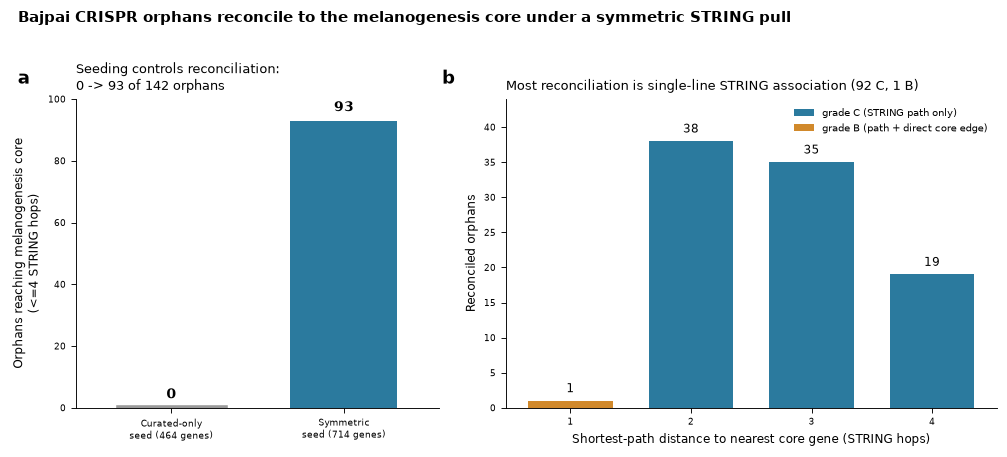

In [ ]:
import matplotlib.pyplot as plt, matplotlib as mpl
# Figure: (a) before/after 0->93; (b) distance-to-core histogram by convergence grade
plt.rcParams.update({'font.size':8,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':8.5,'figure.dpi':110})
META_GREY='#9a9a9a'
rec = recon_df[recon_df.bucket=='reconciled']
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(9.2,4.0),gridspec_kw={'width_ratios':[1,1.35]})

vals=[0,len(rec)]; bars=ax1.bar(['Curated-only\nseed (464 genes)','Symmetric\nseed (714 genes)'],vals,
    color=[META_GREY,'#2b7a9e'],width=0.62,zorder=3)
ax1.set_ylabel('Orphans reaching melanogenesis core\n(<=4 STRING hops)'); ax1.set_ylim(0,100); ax1.margins(x=0.15)
for b,v in zip(bars,vals): ax1.text(b.get_x()+b.get_width()/2,v+2,str(v),ha='center',va='bottom',fontweight='bold',fontsize=9)
ax1.plot([bars[0].get_x(),bars[0].get_x()+bars[0].get_width()],[0.4,0.4],color=META_GREY,lw=3,zorder=4)
ax1.set_title('Seeding controls reconciliation:\n0 -> %d of 142 orphans'%len(rec),loc='left')
ax1.text(-0.16,1.05,'a',transform=ax1.transAxes,fontweight='bold',fontsize=12)

xs=sorted(rec['dist_to_core'].astype(int).unique())
c=[int(((rec.dist_to_core==d)&(rec.convergence_grade=='C')).sum()) for d in xs]
b=[int(((rec.dist_to_core==d)&(rec.convergence_grade=='B')).sum()) for d in xs]
ax2.bar(xs,c,width=0.7,color='#2b7a9e',label='grade C (STRING path only)',zorder=3)
ax2.bar(xs,b,bottom=c,width=0.7,color='#d1892b',label='grade B (path + direct core edge)',zorder=3)
ax2.set_xlabel('Shortest-path distance to nearest core gene (STRING hops)')
ax2.set_ylabel('Reconciled orphans'); ax2.set_xticks(xs); ax2.set_ylim(0,max(ci+bi for ci,bi in zip(c,b))+6)
for d,ci,bi in zip(xs,c,b): ax2.text(d,ci+bi+0.8,str(ci+bi),ha='center',va='bottom',fontsize=8)
ax2.legend(frameon=False,fontsize=6.5,loc='upper right')
ax2.set_title('Most reconciliation is single-line STRING association (%d C, %d B)'%(
    (rec.convergence_grade=='C').sum(),(rec.convergence_grade=='B').sum()),loc='left')
ax2.text(-0.13,1.05,'b',transform=ax2.transAxes,fontweight='bold',fontsize=12)

fig.suptitle('Bajpai CRISPR orphans reconcile to the melanogenesis core under a symmetric STRING pull',
             fontsize=10,fontweight='bold',x=0.02,ha='left',y=1.02)
fig.tight_layout(); fig.savefig(f'{REPO}/notebooks/figures/nb9_orphan_reconciliation.png',dpi=300,bbox_inches='tight')
print('saved figure'); fig


## 7 · What this establishes (and what it does not)

**Establishes.** The orphan status of 142 CRISPR-validated melanin genes was a **seeding artifact**, not
biology. Asking STRING the *symmetric* question (seed on the full union, so both endpoints of every candidate
edge are in the query) reconciles **93/142** to the melanogenesis core within ≤4 hops — up from a structural
**0** under the curated-only seed. This is the project's third "**the choice changes the answer**" result:
source (NB5), tissue (melanocyte-vs-bulk), and now **seeding**.

**Does not establish.** These are **association hypotheses**, not mechanisms. 92 of 93 reconciled orphans rest
on a *single* line of evidence (STRING path); GRN and Reactome corroborate none; 22/93 paths run through a
promiscuous hub. The CRISPR phenotype is the only causal fact — STRING proposes candidate wiring to be tested
(§5). And **49 genes remain a genuine knowledge gap**: causal for melanin, unwired to canonical machinery even
under the symmetric pull. Both halves are the finding.